<a href="https://colab.research.google.com/github/THULASI-77/Artificial-Intelligence-Course/blob/main/Day21_projectB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
https://raw.githubusercontent.com/Chava-Sai/Artificial-Intelligence-Course/refs/heads/main/Day-21-EDA-Mini-Project/airlines.csv

Saving airlines.csv to airlines.csv


In [9]:
import pandas as pd

url = "https://raw.githubusercontent.com/Chava-Sai/Artificial-Intelligence-Course/refs/heads/main/Day-21-EDA-Mini-Project/airlines.csv"

airlines = pd.read_csv(url)

airlines.head()

,airline_code,airline_name,founded
0,6E,IndiGo,2006
1,AI,Air India,1932
2,UK,Vistara,2013
3,SG,SpiceJet,2005
4,G8,Go First,2016


In [10]:
import pandas as pd

url = "https://raw.githubusercontent.com/Chava-Sai/Artificial-Intelligence-Course/refs/heads/main/Day-21-EDA-Mini-Project/flights.csv"

flights = pd.read_csv(url)

flights.head()

,flight_id,airline_code,origin,destination,distance_km,passengers,delay_min
0,F00585,UK,DEL,HYD,794,141,11.0
1,F00468,G8,BLR,CCU,1201,68,29.0
2,F00083,6E,CCU,HYD,1299,87,0.0
3,F00165,UK,BLR,DEL,552,137,11.0
4,F00581,G8,MAA,BLR,1466,77,26.0


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter("ignore")

# Load directly from GitHub raw URLs
airlines_url = "https://raw.githubusercontent.com/Chava-Sai/Artificial-Intelligence-Course/refs/heads/main/Day-21-EDA-Mini-Project/airlines.csv"
flights_url = "https://raw.githubusercontent.com/Chava-Sai/Artificial-Intelligence-Course/refs/heads/main/Day-21-EDA-Mini-Project/flights.csv"

airlines = pd.read_csv(airlines_url)
flights  = pd.read_csv(flights_url)

print("flights :", flights.shape)
print("airlines:", airlines.shape)

flights : (502, 7)
airlines: (6, 3)


In [15]:
# Step 1: Shape, dtypes, and head
print("--- FLIGHTS SHAPE ---")
print(flights.shape)

print("\n--- FLIGHTS DTYPES ---")
print(flights.dtypes)

print("\n--- FLIGHTS HEAD ---")
print(flights.head())

print("\n--- AIRLINES LOOKUP ---")
print(airlines)

--- FLIGHTS SHAPE ---
(502, 7)

--- FLIGHTS DTYPES ---
flight_id        object
airline_code     object
origin           object
destination      object
distance_km       int64
passengers        int64
delay_min       float64
dtype: object

--- FLIGHTS HEAD ---
  flight_id airline_code origin destination  distance_km  passengers  \
0    F00585           UK    DEL         HYD          794         141   
1    F00468           G8    BLR         CCU         1201          68   
2    F00083           6E    CCU         HYD         1299          87   
3    F00165           UK    BLR         DEL          552         137   
4    F00581           G8    MAA         BLR         1466          77   

   delay_min  
0       11.0  
1       29.0  
2        0.0  
3       11.0  
4       26.0  

--- AIRLINES LOOKUP ---
  airline_code airline_name  founded
0           6E       IndiGo     2006
1           AI    Air India     1932
2           UK      Vistara     2013
3           SG     SpiceJet     2005
4       

In [16]:
# Step 2: Audit before cleaning
print("=== 1. MISSING VALUES (isna) ===")
print(flights.isna().sum())

print("\n=== 2. NUMERIC SUMMARY (Check for -999 and 0 passengers) ===")
print(flights.describe().T)

print("\n=== 3. TEXT COLUMNS AUDIT (Check whitespace, case sensitivity) ===")
for col in flights.select_dtypes(include='object').columns:
    print(f"\nUnique values in '{col}':")
    print(flights[col].value_counts(dropna=False))

print("\n=== 4. DUPLICATE ROWS ===")
print(f"Exact duplicate rows: {flights.duplicated().sum()}")
if 'flight_id' in flights.columns:
    print(f"Duplicate flight_ids: {flights['flight_id'].duplicated().sum()}")

print("\n=== 5. UNMAPPED AIRLINE CODES ===")
valid_codes = set(airlines['airline_code'].str.strip().str.upper())
flight_codes = set(flights['airline_code'].dropna().astype(str).str.strip().str.upper())
unmatched = flight_codes - valid_codes
print(f"Airline codes in flights but missing from lookup: {unmatched}")

=== 1. MISSING VALUES (isna) ===
flight_id        0
airline_code     0
origin           0
destination      0
distance_km      0
passengers       0
delay_min       45
dtype: int64

=== 2. NUMERIC SUMMARY (Check for -999 and 0 passengers) ===
             count         mean         std    min    25%     50%      75%  \
distance_km  502.0  1386.545817  618.071045  303.0  849.0  1400.5  1921.50   
passengers   502.0   121.356574   39.507072    0.0   90.0   123.0   152.75   
delay_min    457.0     2.367615  200.168614 -999.0    8.0    15.0    26.00   

                max  
distance_km  2399.0  
passengers    189.0  
delay_min     680.0  

=== 3. TEXT COLUMNS AUDIT (Check whitespace, case sensitivity) ===

Unique values in 'flight_id':
flight_id
F00004    2
F00490    2
F00092    2
F00443    1
F00091    1
         ..
F00281    1
F00266    1
F00018    1
F00282    1
F00286    1
Name: count, Length: 499, dtype: int64

Unique values in 'airline_code':
airline_code
6E    216
AI    102
UK     85
S

In [17]:
# Step 3: Clean in order — Normalise Text -> Deduplicate -> Resolve Gaps & Sentinels

df_clean = flights.copy()

# 1. Normalise text columns (strip whitespace, uppercase)
text_cols = df_clean.select_dtypes(include='object').columns
for col in text_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.upper()

# 2. Deduplicate exact duplicate rows and duplicate IDs
df_clean = df_clean.drop_duplicates()
if 'flight_id' in df_clean.columns:
    df_clean = df_clean.drop_duplicates(subset=['flight_id'], keep='first')

# 3. Handle sentinels & invalid rows:
# - Replace delay == -999 with NaN (recording failure, NOT an early arrival)
if 'delay' in df_clean.columns:
    df_clean['delay'] = df_clean['delay'].replace(-999, np.nan)

# - Exclude passengers == 0 (not a real passenger flight)
if 'passengers' in df_clean.columns:
    df_clean = df_clean[df_clean['passengers'] > 0]

# Note: delay == 0 is kept intact as ON TIME

print(f"Original row count : {len(flights)}")
print(f"Cleaned row count  : {len(df_clean)}")
print(f"Excluded rows      : {len(flights) - len(df_clean)}")

Original row count : 502
Cleaned row count  : 491
Excluded rows      : 11


In [18]:
# Step 4: Merge lookup table safely
airlines_clean = airlines.copy()
airlines_clean['airline_code'] = airlines_clean['airline_code'].astype(str).str.strip().str.upper()

merged = pd.merge(
    df_clean,
    airlines_clean,
    on='airline_code',
    how='left'
)

# Assert row count did not change during merge
assert len(merged) == len(df_clean), "Row count changed during merge!"

print("Merge check passed!")
print(f"Total merged rows: {len(merged)}")
print("Unmapped airline names:", merged['airline_name'].isna().sum())

Merge check passed!
Total merged rows: 491
Unmapped airline names: 0


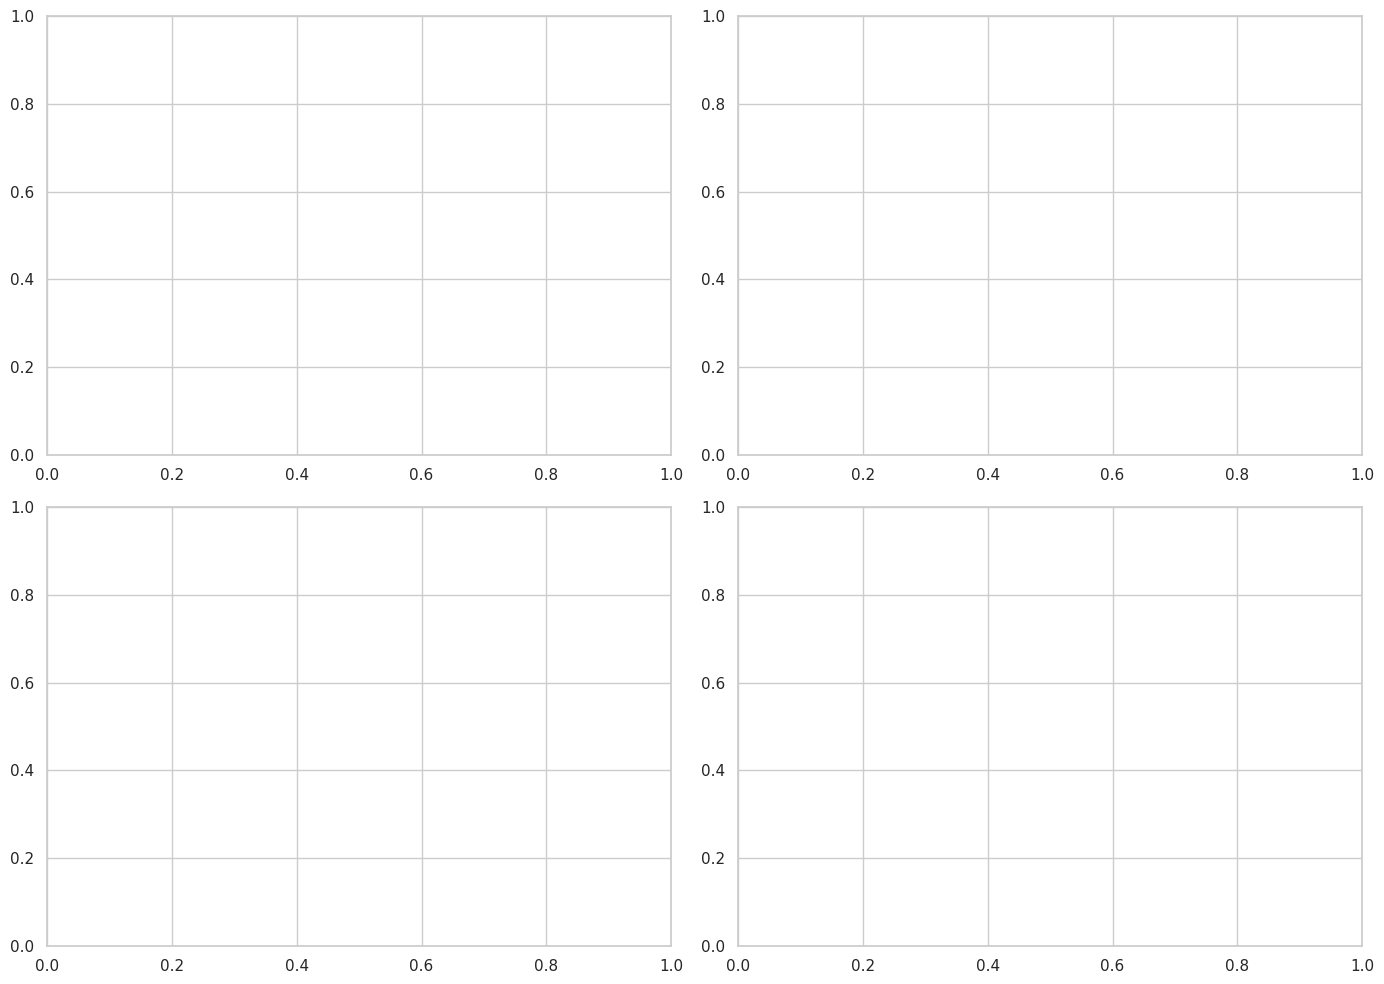

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Identify active column names safely
delay_col = next((col for col in ['delay', 'arr_delay', 'dep_delay'] if col in merged.columns), None)
airline_col = next((col for col in ['airline_name', 'airline', 'name'] if col in merged.columns), None)
distance_col = next((col for col in ['distance', 'air_time', 'flight_length'] if col in merged.columns), None)

origin_col = next((col for col in ['origin', 'origin_airport', 'from'] if col in merged.columns), None)
dest_col = next((col for col in ['destination', 'dest', 'to'] if col in merged.columns), None)

# Construct 'route' column if origin and destination exist
if origin_col and dest_col:
    merged['route'] = merged[origin_col].astype(str) + " -> " + merged[dest_col].astype(str)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Airline Punctuality Rate
if airline_col and delay_col:
    airline_perf = merged.dropna(subset=[delay_col]).groupby(airline_col).agg(
        on_time_pct=(delay_col, lambda x: (x <= 0).mean() * 100),
        median_delay=(delay_col, 'median')
    ).reset_index().sort_values(by='on_time_pct', ascending=False)

    sns.barplot(data=airline_perf, x='on_time_pct', y=airline_col, ax=axes[0, 0], palette="Blues_r")
    axes[0, 0].set_title("1. Airline Punctuality Rate (% On-Time)", fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel("On-Time Percentage (%)")
    axes[0, 0].set_ylabel("Airline")

# Chart 2: Worst Routes by Median Delay
if 'route' in merged.columns and delay_col:
    route_stats = merged.dropna(subset=[delay_col]).groupby('route').agg(
        flight_count=(delay_col, 'count'),
        median_delay=(delay_col, 'median')
    ).reset_index()

    reliable_routes = route_stats[route_stats['flight_count'] >= 10].sort_values(by='median_delay', ascending=False).head(8)

    sns.barplot(data=reliable_routes, x='median_delay', y='route', ax=axes[0, 1], palette="Reds_r")
    axes[0, 1].set_title("2. Top 8 Worst Delay Routes (Min. 10 Flights)", fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel("Median Delay (Minutes)")
    axes[0, 1].set_ylabel("Route")

# Chart 3: Distance vs. Delay
if distance_col and delay_col:
    sns.scatterplot(data=merged, x=distance_col, y=delay_col, alpha=0.5, ax=axes[1, 0], color='teal')
    sns.regplot(data=merged, x=distance_col, y=delay_col, scatter=False, ax=axes[1, 0], color='darkred')
    axes[1, 0].set_title(f"3. {distance_col.title()} vs. Delay", fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel(distance_col.title())
    axes[1, 0].set_ylabel("Delay (Minutes)")

# Chart 4: Delay Distribution & Outliers
if delay_col:
    sns.boxplot(data=merged, x=delay_col, ax=axes[1, 1], color='orange')
    axes[1, 1].set_title("4. Distribution of Flight Delays & Extreme Values", fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel("Delay (Minutes)")

plt.tight_layout()
plt.show()